# Activator-target model: a minimal demonstration of processivity-driven quantization

This notebook accompanies Box 1 of *Mathematical modeling predicts quantization of Ras activation in membrane corrals*. It implements the minimal two-layer cascade described in the Box and shows that, when the four conditions are met simultaneously, the steady-state distribution of the target species exhibits well-resolved peaks at integer multiples of the activator quantum — with continuous (non-zero) density between them.

**Model.** An activator $A$ is converted to its active form $A^*$ at rate $k_1$ per inactive molecule and deactivates at rate $k_{-1}$. Each $A^*$ catalyzes the activation of a target species, $A^* + T \to A^* + T^*$, with rate constant $k_2$. Target deactivation is first-order with rate $k_{-2}$. There is no binding step between $A^*$ and $T$ — this is the cleanest possible illustration of the framework, with all the biochemistry of complex formation (cf. SOS-Ras) stripped away.

**Conditions for quantization.** Defining the per-quantum peak spacing $\Delta = k_2 T_T / k_{-2}$ and using $\tau_{A^*} = 1/k_{-1}$, $\tau_{T^*|n} = 1/(n k_2 + k_{-2})$:

1. Low activator number: $A_T k_1 / k_{-1} \sim 1$
2. Resolvable spacing: $\Delta \gg 1$
3. Timescale separation: $k_{-2} / k_{-1} \gg 1$, equivalently $\tau_{T^*|n} \ll \tau_{A^*}$
4. Unsaturated catalysis: $n k_2 / k_{-2} \lesssim 1$ for relevant $n$

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson

rng = np.random.default_rng(7)

# Parameters chosen to satisfy all four conditions (see Box 1)
AT  = 10          # total activator molecules
TT  = 1000        # total target molecules
k1  = 1e-3        # activator on-rate (s^-1)
km1 = 1e-2        # activator off-rate (s^-1); tau_A* = 100 s
k2  = 2.5e-2      # catalytic activation rate per A* (s^-1)
km2 = 0.5         # target deactivation rate (s^-1); tau_T*|0 = 2 s

# Diagnostic dimensionless numbers
mean_Astar_pred = AT * k1 / (k1 + km1)
Delta = k2 * TT / km2                   # peak spacing in target molecule count
phi   = k2 * TT / km1                   # processivity per A* lifetime
tau_ratio = km2 / km1                   # tau_A* / tau_T*|0
sat = lambda n: n * k2 / km2            # saturation parameter

print(f'Predicted mean A*           = {mean_Astar_pred:.3f}')
print(f'Peak spacing  Delta         = {Delta:.1f} molecules')
print(f'Processivity  phi           = {phi:.1f}')
print(f'Timescale ratio km2/km1     = {tau_ratio:.0f}')
print(f'Saturation at n=5: n*k2/km2 = {sat(5):.3f}')

Predicted mean A*           = 0.909
Peak spacing  Delta         = 50.0 molecules
Processivity  phi           = 2500.0
Timescale ratio km2/km1     = 50
Saturation at n=5: n*k2/km2 = 0.250


## Stochastic simulation

We use the Gillespie algorithm directly. The reactions are:

| # | Reaction | Propensity |
|---|---|---|
| 1 | $A \to A^*$ | $k_1 \cdot A$ |
| 2 | $A^* \to A$ | $k_{-1} \cdot A^*$ |
| 3 | $T + A^* \to T^* + A^*$ | $k_2 \cdot A^* \cdot T$ |
| 4 | $T^* \to T$ | $k_{-2} \cdot T^*$ |

An equivalent BioNetGen specification is provided in `ActivatorTarget.bngl` for reproducibility within the rule-based framework used in the rest of the manuscript.

In [2]:
def simulate_activator_target(AT, TT, k1, km1, k2, km2, t_end, n_grid, rng):
    """Direct Gillespie SSA. Returns time grid and observable trajectories."""
    A, Astar = AT, 0
    T, Tstar = TT, 0
    t = 0.0
    t_grid = np.linspace(0, t_end, n_grid)
    Astar_traj = np.zeros(n_grid, dtype=np.int32)
    Tstar_traj = np.zeros(n_grid, dtype=np.int32)
    idx = 0
    while t < t_end:
        a1 = k1 * A
        a2 = km1 * Astar
        a3 = k2 * Astar * T
        a4 = km2 * Tstar
        a_tot = a1 + a2 + a3 + a4
        if a_tot == 0:
            break
        dt = -np.log(rng.random()) / a_tot
        t_new = t + dt
        # Backfill the grid up to t_new with the current state
        while idx < n_grid and t_grid[idx] < t_new:
            Astar_traj[idx] = Astar
            Tstar_traj[idx] = Tstar
            idx += 1
        if idx >= n_grid:
            break
        # Choose and fire one reaction
        r = rng.random() * a_tot
        if r < a1:
            A -= 1; Astar += 1
        elif r < a1 + a2:
            A += 1; Astar -= 1
        elif r < a1 + a2 + a3:
            T -= 1; Tstar += 1
        else:
            T += 1; Tstar -= 1
        t = t_new
    return t_grid, Astar_traj, Tstar_traj

t_end = 100_000.0       # 1000 activator lifetimes -> good Poisson statistics
n_grid = 100_001
t_grid, Astar_traj, Tstar_traj = simulate_activator_target(
    AT, TT, k1, km1, k2, km2, t_end, n_grid, rng)

# Discard the first 5% as burn-in
burn = n_grid // 20
df = pd.DataFrame({
    'time':  t_grid[burn:],
    'Astar': Astar_traj[burn:],
    'Tstar': Tstar_traj[burn:],
})

print(f'Simulated {t_end:.0f} s with {n_grid-1} samples')
print(f'Empirical mean A* = {df.Astar.mean():.3f}  (Poisson prediction = {mean_Astar_pred:.3f})')
print(f'Empirical mean T* = {df.Tstar.mean():.2f}')

Simulated 100000 s with 100000 samples
Empirical mean A* = 0.894  (Poisson prediction = 0.909)
Empirical mean T* = 41.18


## Analytical predictions

When the timescale separation condition holds, the target conditional on a fixed activator count $n$ relaxes to a quasi-steady-state binomial distribution:

$$P(T^* = k \mid n) = \binom{T_T}{k} p_n^k (1-p_n)^{T_T - k}, \qquad p_n = \frac{n k_2}{n k_2 + k_{-2}}$$

with mean $\langle T^* \rangle_n = T_T p_n$ and variance $\sigma_n^2 = T_T p_n (1-p_n)$. The activator distribution is approximately Poisson with mean $A_T k_1 / k_{-1}$, since $k_1 \ll k_{-1}$ keeps activation rare. The full target distribution is the mixture

$$P(T^*) = \sum_{n=0}^{A_T} P(n) \, P(T^* \mid n)$$

We compute this prediction now and overlay it on the empirical histogram.

In [3]:
# Activator distribution: exact (truncated Poisson on 0..AT)
n_vals = np.arange(0, AT + 1)
Pn_poisson = poisson.pmf(n_vals, mean_Astar_pred)
Pn = Pn_poisson / Pn_poisson.sum()        # renormalize for finite AT

# Conditional binomial for each n: precompute on integer support 0..TT
k_vals = np.arange(0, TT + 1)
P_T_given_n = np.zeros((len(n_vals), len(k_vals)))
for i, n in enumerate(n_vals):
    p_n = n * k2 / (n * k2 + km2) if n > 0 else 0.0
    if n == 0:
        P_T_given_n[i, 0] = 1.0           # T* stuck at 0 with no activator
    else:
        P_T_given_n[i] = binom.pmf(k_vals, TT, p_n)

# Mixture distribution
P_T_total = (Pn[:, None] * P_T_given_n).sum(axis=0)

# Print peak positions and widths
print('  n   P(n)    <T*>_n   sigma_n')
for n in range(7):
    p_n = n * k2 / (n * k2 + km2) if n > 0 else 0.0
    mean_n = TT * p_n
    sd_n = np.sqrt(TT * p_n * (1 - p_n)) if n > 0 else 0.0
    print(f'  {n}   {Pn[n]:.4f}  {mean_n:6.1f}   {sd_n:5.2f}')

  n   P(n)    <T*>_n   sigma_n
  0   0.4029     0.0    0.00
  1   0.3663    47.6    6.73
  2   0.1665    90.9    9.09
  3   0.0504   130.4   10.65
  4   0.0115   166.7   11.79
  5   0.0021   200.0   12.65
  6   0.0003   230.8   13.32


## Figure: simulation vs. theory

Top row: a representative segment of the activator and target trajectories. Bottom row: the empirical target distribution overlaid with the analytical mixture (left) and the conditional distributions decomposed by activator state (right). The activator distribution itself is shown as an inset.

The theoretical mixture (black curve, bottom-left) tracks the simulation closely. Each peak corresponds to a discrete activator quantum, and the density between peaks is non-zero — composed of the binomial tails of adjacent quanta plus transient mass from times when the system is mid-relaxation between activator turnover events.

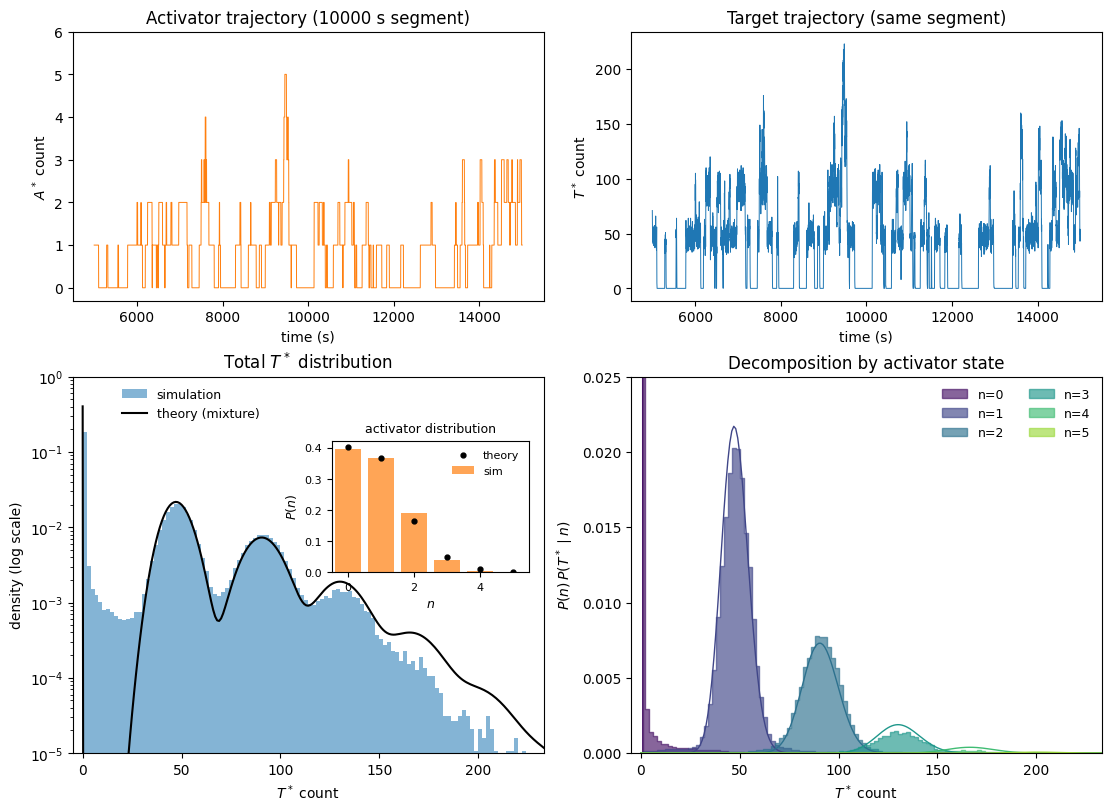

In [12]:
fig = plt.figure(figsize=(11, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.4])

# --- Top-left: A* trajectory segment ---
ax_at = fig.add_subplot(gs[0, 0])
seg = (df.time > 5000) & (df.time < 15000)
ax_at.plot(df.time[seg], df.Astar[seg], color='C1', lw=0.7)
ax_at.set_xlabel('time (s)')
ax_at.set_ylabel(r'$A^*$ count')
ax_at.set_title('Activator trajectory (10000 s segment)')
ax_at.set_ylim(-0.3, max(6, df.Astar[seg].max() + 0.5))

# --- Top-right: T* trajectory segment ---
ax_tt = fig.add_subplot(gs[0, 1])
ax_tt.plot(df.time[seg], df.Tstar[seg], color='C0', lw=0.7)
ax_tt.set_xlabel('time (s)')
ax_tt.set_ylabel(r'$T^*$ count')
ax_tt.set_title('Target trajectory (same segment)')

# --- Bottom-left: empirical T* histogram + analytical mixture (log y) ---
ax_h = fig.add_subplot(gs[1, 0])
bin_w = 2
x_max = max(220, df.Tstar.max() + 10)
bins = np.arange(0, x_max + bin_w + 1, bin_w)
ax_h.hist(df.Tstar, bins=bins, density=True, color='C0', alpha=0.55,
          edgecolor='none', label='simulation')
ax_h.plot(k_vals, P_T_total, 'k-', lw=1.5, label='theory (mixture)')
ax_h.set_xlim(-5, x_max)
ax_h.set_ylim(1e-5, 1)
ax_h.set_yscale('log')
ax_h.set_xlabel(r'$T^*$ count')
ax_h.set_ylabel('density (log scale)')
ax_h.set_title('Total $T^*$ distribution')
ax_h.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.08, 1), fontsize=9)

# Inset showing A* distribution (empirical bars + Poisson dots)
ax_inset = ax_h.inset_axes([0.55, 0.48, 0.42, 0.35])
Astar_vals, Astar_counts = np.unique(df.Astar, return_counts=True)
Astar_pmf = Astar_counts / Astar_counts.sum()
ax_inset.bar(Astar_vals, Astar_pmf, color='C1', alpha=0.7,
             edgecolor='none', label='sim')
ax_inset.plot(n_vals, Pn, 'ko', ms=3.5, label='theory')
ax_inset.set_xlim(-0.5, max(5, Astar_vals.max()) + 0.5)
ax_inset.set_xlabel(r'$n$', fontsize=9)
ax_inset.set_ylabel(r'$P(n)$', fontsize=9)
ax_inset.set_title('activator distribution', fontsize=9)
ax_inset.tick_params(labelsize=8)
ax_inset.legend(frameon=False, fontsize=8, loc='upper right')

# --- Bottom-right: T* histograms decomposed by A* (linear, weighted by P(n)) ---
ax_c = fig.add_subplot(gs[1, 1])
n_show = min(int(df.Astar.max()), 5)
cmap = plt.cm.viridis(np.linspace(0.05, 0.85, n_show + 1))
for n in range(n_show + 1):
    mask = df.Astar == n
    if mask.sum() < 50:
        continue
    weight = mask.sum() / len(df)
    counts, edges = np.histogram(df.Tstar[mask], bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax_c.fill_between(centers, counts * weight, step='mid',
                      color=cmap[n], alpha=0.65, label=f'n={n}')
    ax_c.plot(k_vals, P_T_given_n[n] * Pn[n], color=cmap[n], lw=1.0)
# Skip n=0 for the linear y-axis — its delta function dominates.
ax_c.set_xlim(-5, x_max)
ax_c.set_ylim(0, 0.025)
ax_c.set_xlabel(r'$T^*$ count')
ax_c.set_ylabel(r'$P(n)\,P(T^* \mid n)$')
ax_c.set_title('Decomposition by activator state')
ax_c.legend(frameon=False, ncol=2, fontsize=9, loc='upper right')

plt.savefig('activator_target_figure.pdf', dpi=300, bbox_inches='tight')
plt.savefig('activator_target_figure.png', dpi=200, bbox_inches='tight')
plt.show()

## Verification that the four conditions hold

We close by tabulating the four dimensionless conditions for the parameter set used.

In [5]:
checks = pd.DataFrame([
    ('1. Low activator number',  'AT*k1/km1',           AT*k1/km1,          '~ 1'),
    ('2. Resolvable spacing',    'Delta = k2*TT/km2',   Delta,              '>> 1'),
    ('3. Timescale separation',  'km2/km1',             km2/km1,            '>> 1'),
    ('4a. Unsaturated at n=1',   '1*k2/km2',            sat(1),             '<~ 1'),
    ('4b. Unsaturated at n=5',   '5*k2/km2',            sat(5),             '<~ 1'),
], columns=['condition', 'expression', 'value', 'target'])
checks

,condition,expression,value,target
0,1. Low activator number,AT*k1/km1,1.00,~ 1
1,2. Resolvable spacing,Delta = k2*TT/km2,50.00,>> 1
2,3. Timescale separation,km2/km1,50.00,>> 1
3,4a. Unsaturated at n=1,1*k2/km2,0.05,<~ 1
4,4b. Unsaturated at n=5,5*k2/km2,0.25,<~ 1


## Notes on the parameter choice

The peak spacing $\Delta = 50$ molecules and conditional widths $\sigma_n \approx \sqrt{n \Delta}$ give a peak-to-width ratio of order $\sqrt{\Delta / n}$, which is ${\sim}7$ at $n=1$ and decreases mildly for larger $n$ as adjacent peaks crowd. This is the regime where individual quanta remain resolvable while still showing the binomial tails that fill in the density between peaks — the visual signature that distinguishes a mixture-of-binomials from a true mixture of stable steady states.

Increasing $k_{-2}$ further would shrink the peaks (lower $\Delta$) and eventually unmask the central limit regime where the distribution becomes unimodal. Decreasing $k_{-1}$ further would extend the activator lifetime; the steady-state target distribution is invariant to this rescaling so long as conditions 3 and 4 continue to hold, but the trajectories become slower.